# A Predictive Model for US Airline Flight Delays - Decision Forests

### <span style="color:chocolate"> Project Description </span>

Flight delay prediction is an important research field, as flight delays are the primary concern of aviation
stakeholders. Our project aims to identify the predictors of flight delays before they happen, improve
travelers experience, and help airlines shift from reactive damage control to proactive delay management.

---
### <span style="color:chocolate">Import libraries</span>

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier

from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

---
### <span style="color:chocolate">Data Ingestion</span>

Reading the cleaned and combined data from 2022 to 2026 to the data frame downloaded from the following data sources:
- Flight data: Bureau of transportation stats https://www.transtats.bts.gov/ontime/
- Weather data (New with 2026 data): https://www.ncei.noaa.gov/access/search/data-search/global-historical-climatology-network-hourly
- Aircraft data: https://www.faa.gov/licenses_certificates/aircraft_certification/aircraft_registry/releasable_aircraft_download?utm_source=chatgpt.com

In [2]:
# Read in the data.
flight_df = pd.read_csv('Data/combined_data_1h.csv')

In [3]:
# Sort the row by the values in 'date' column
flight_df = flight_df.sort_values('date').reset_index(drop=True)

In [4]:
# Display the first five rows of data.
flight_df.head()

,date,scheduled_dep_dt,actual_dep_dt,carrier_code,destination_airport,scheduled_elapsed_time_minutes,year,month,day_of_week,is_weekend,...,dew_point_temperature,relative_humidity,altimeter,aircraft_age,week_num,temperature_dewpoint_spread,airport_delay_average_1h,airport_delay_stddev_1h,airport_departures_observed_1h,departure_delay_minutes
0,2022-01-01,2022-01-01 05:25:00,2022-01-01 05:25:00,WN,DEN,145.0,2022.0,1.0,5.0,1,...,5.0,74.0,1014.6,16.0,1,4.4,0.000000,0.000000,0.0,0.0
1,2022-01-01,2022-01-01 18:25:00,2022-01-01 18:42:00,UA,PDX,110.0,2022.0,1.0,5.0,1,...,3.3,79.0,1023.0,15.0,1,3.4,20.100000,22.133183,10.0,17.0
2,2022-01-01,2022-01-01 18:25:00,2022-01-01 18:39:00,UA,ORD,253.0,2022.0,1.0,5.0,1,...,3.3,79.0,1023.0,8.0,1,3.4,20.100000,22.133183,10.0,14.0
3,2022-01-01,2022-01-01 18:12:00,2022-01-01 18:03:00,F9,PHX,122.0,2022.0,1.0,5.0,1,...,3.3,79.0,1023.0,4.0,1,3.4,15.200000,21.006877,10.0,-9.0
4,2022-01-01,2022-01-01 18:05:00,2022-01-01 18:37:00,WN,PHX,120.0,2022.0,1.0,5.0,1,...,3.3,79.0,1023.0,4.0,1,3.4,13.818182,20.449050,11.0,32.0


In [5]:
# Display the shape
flight_df.shape

(334086, 32)

In [6]:
# Check the types of each column
flight_df.dtypes

date                               object
scheduled_dep_dt                   object
actual_dep_dt                      object
carrier_code                       object
destination_airport                object
scheduled_elapsed_time_minutes    float64
year                              float64
month                             float64
day_of_week                       float64
is_weekend                          int64
sched_dep_hour                    float64
outcome                           float64
days_until_holiday                float64
days_from_holiday                 float64
year_mfr                          float64
model                              object
no_seats                          float64
visibility                        float64
ceiling_height                    float64
wind_speed                        float64
wind_direction                    float64
temperature                       float64
dew_point_temperature             float64
relative_humidity                 

In [7]:
# Check if there is any missing values.
flight_df.isna().values.any()

np.False_

---
#### <span style="color:chocolate">Data Preprocessing</span>



In [7]:
# Assigned the duration of departure delay into different category.
def delay_category(row):
    delay = row['departure_delay_minutes']
    # (1) No delay
    if delay <= 0:
        return 0
    #(2) Less than 1 hour
    elif delay < 60:
        return 1
    # (3) 1 - 2 hour
    elif delay < 120:
        return 2
    # (4) 2 to 3 hours
    elif delay < 180:
        return 3
    # (5) 3 to 4 hours
    elif delay < 240:
        return 4
    # (6) 4 to 5 hours
    elif delay < 300:
        return 5
    # (7) 5 to 6 hours
    elif delay < 360:
        return 6
    else:
    # (8) Cancelled
        return 7

In [8]:
# Create a new column in the dataframe to save the target output.
flight_df['target'] = flight_df.apply(delay_category, axis=1)

In [9]:
# Group the numeric features together.
features_numeric = [
    'scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend',
    'sched_dep_hour', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'no_seats',
    'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature',
    'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num',
    'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h',
    'airport_departures_observed_1h'
]

In [10]:
# Group the categorical features together.
features_categorical = ['carrier_code', 'destination_airport', 'model']

In [11]:
for col in features_categorical:
    flight_df[col] = flight_df[col].astype('category')

In [12]:
all_features = features_numeric + features_categorical

In [13]:
# Calculate the number of samples based on the split percentage then save the indexes number.
total_rows = len(flight_df)
train_end_idx = int(total_rows * 0.60)
val_end_idx = train_end_idx + int(total_rows * 0.20)

In [14]:
# Split the data
df_train = flight_df.iloc[:train_end_idx]
df_val   = flight_df.iloc[train_end_idx:val_end_idx]
df_test  = flight_df.iloc[val_end_idx:]

In [15]:
df_train.head()

,date,scheduled_dep_dt,actual_dep_dt,carrier_code,destination_airport,scheduled_elapsed_time_minutes,year,month,day_of_week,is_weekend,...,relative_humidity,altimeter,aircraft_age,week_num,temperature_dewpoint_spread,airport_delay_average_1h,airport_delay_stddev_1h,airport_departures_observed_1h,departure_delay_minutes,target
0,2022-01-01,2022-01-01 05:25:00,2022-01-01 05:25:00,WN,DEN,145.0,2022.0,1.0,5.0,1,...,74.0,1014.6,16.0,1,4.4,0.000000,0.000000,0.0,0.0,0
1,2022-01-01,2022-01-01 18:25:00,2022-01-01 18:42:00,UA,PDX,110.0,2022.0,1.0,5.0,1,...,79.0,1023.0,15.0,1,3.4,20.100000,22.133183,10.0,17.0,1
2,2022-01-01,2022-01-01 18:25:00,2022-01-01 18:39:00,UA,ORD,253.0,2022.0,1.0,5.0,1,...,79.0,1023.0,8.0,1,3.4,20.100000,22.133183,10.0,14.0,1
3,2022-01-01,2022-01-01 18:12:00,2022-01-01 18:03:00,F9,PHX,122.0,2022.0,1.0,5.0,1,...,79.0,1023.0,4.0,1,3.4,15.200000,21.006877,10.0,-9.0,0
4,2022-01-01,2022-01-01 18:05:00,2022-01-01 18:37:00,WN,PHX,120.0,2022.0,1.0,5.0,1,...,79.0,1023.0,4.0,1,3.4,13.818182,20.449050,11.0,32.0,1


In [16]:
# Synchronize final feature collection arrays
X_train = df_train[all_features]
y_train = df_train['target']

X_val   = df_val[all_features]
y_val   = df_val['target']

X_test  = df_test[all_features]
y_test  = df_test['target']

In [17]:
# Display the first five rows of X_train.
print(X_train)

        scheduled_elapsed_time_minutes    year  month  day_of_week  \
0                                145.0  2022.0    1.0          5.0   
1                                110.0  2022.0    1.0          5.0   
2                                253.0  2022.0    1.0          5.0   
3                                122.0  2022.0    1.0          5.0   
4                                120.0  2022.0    1.0          5.0   
...                                ...     ...    ...          ...   
200446                           235.0  2024.0    8.0          2.0   
200447                           238.0  2024.0    8.0          2.0   
200448                           287.0  2024.0    8.0          2.0   
200449                           132.0  2024.0    8.0          2.0   
200450                           222.0  2024.0    8.0          2.0   

        is_weekend  sched_dep_hour  days_until_holiday  days_from_holiday  \
0                1             5.0                 0.0                0.0   
1    

---
### <span style="color:chocolate">Exploratory data analysis (EDA)</span>

In [19]:
df_train = pd.DataFrame(X_train)
df_train['target'] = y_train

In [20]:
df_train.head()

,scheduled_elapsed_time_minutes,year,month,day_of_week,is_weekend,sched_dep_hour,days_until_holiday,days_from_holiday,year_mfr,no_seats,...,aircraft_age,week_num,temperature_dewpoint_spread,airport_delay_average_1h,airport_delay_stddev_1h,airport_departures_observed_1h,carrier_code,destination_airport,model,target
0,145.0,2022.0,1.0,5.0,1,5.0,0.0,0.0,2006.0,149.0,...,16.0,1,4.4,0.000000,0.000000,0.0,WN,DEN,737-76N,0
1,110.0,2022.0,1.0,5.0,1,18.0,0.0,0.0,2007.0,179.0,...,15.0,1,3.4,20.100000,22.133183,10.0,UA,PDX,A319-132,1
2,253.0,2022.0,1.0,5.0,1,18.0,0.0,0.0,2014.0,191.0,...,8.0,1,3.4,20.100000,22.133183,10.0,UA,ORD,737-924ER,1
3,122.0,2022.0,1.0,5.0,1,18.0,0.0,0.0,2018.0,190.0,...,4.0,1,3.4,15.200000,21.006877,10.0,F9,PHX,A320-251N,0
4,120.0,2022.0,1.0,5.0,1,18.0,0.0,0.0,2018.0,175.0,...,4.0,1,3.4,13.818182,20.449050,11.0,WN,PHX,737-800,1


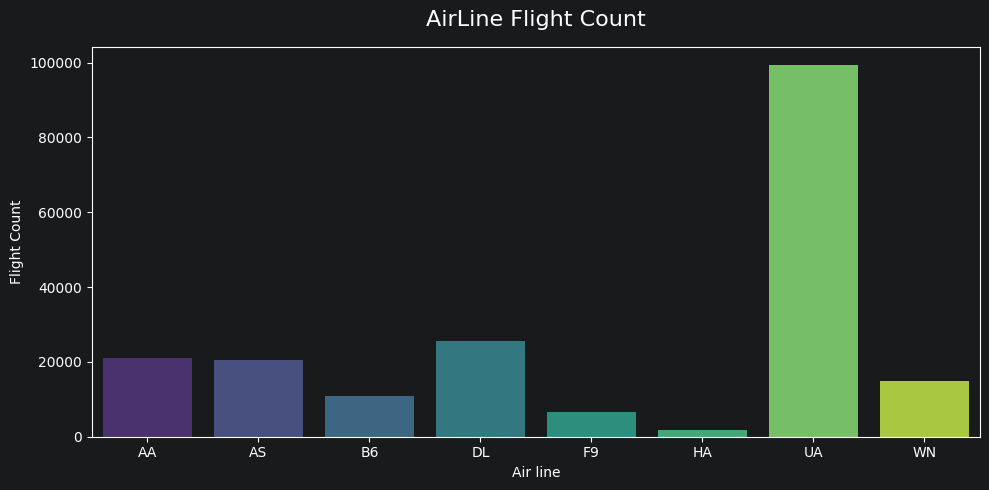

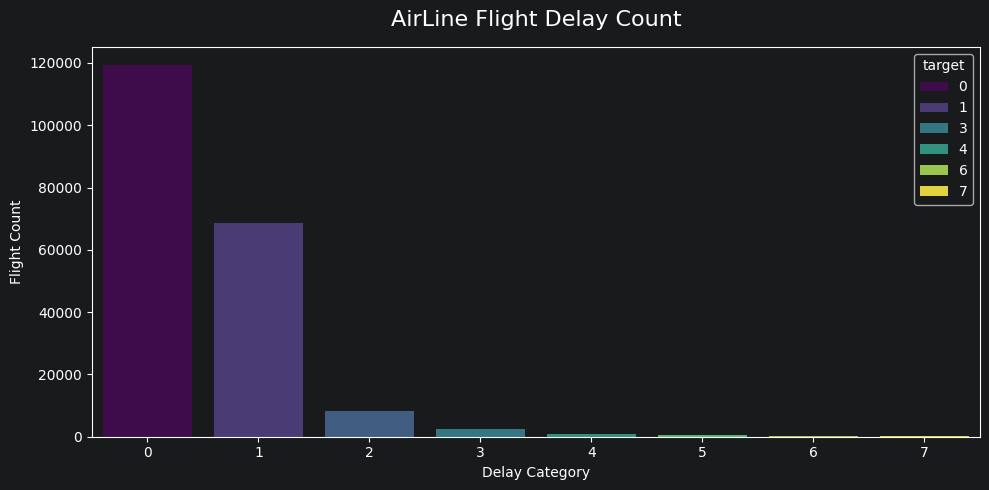

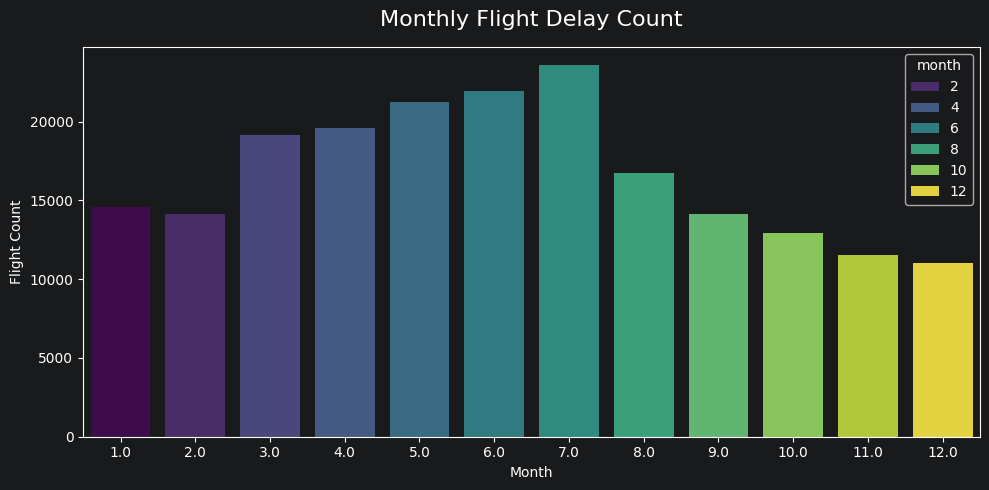

In [21]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5))

# Plot the airline count delay histogram
sns.countplot(data=df_train, x='carrier_code', hue='carrier_code', palette='viridis', color='gold')
plt.title('AirLine Flight Count', fontsize=16, pad=15)
plt.xlabel('Air line', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

# Set up the matplotlib figure
plt.figure(figsize=(10, 5))

# Plot the flight count histogram
sns.countplot(data=df_train, x='target', hue='target', palette='viridis', color='gold')
plt.title('AirLine Flight Delay Count', fontsize=16, pad=15)
plt.xlabel('Delay Category', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

# Set up the matplotlib figure
plt.figure(figsize=(10, 5))

# Plot the monthly flight count delay histogram
sns.countplot(data=df_train, x='month', hue='month', palette='viridis', color='gold')
plt.title('Monthly Flight Delay Count', fontsize=16, pad=15)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

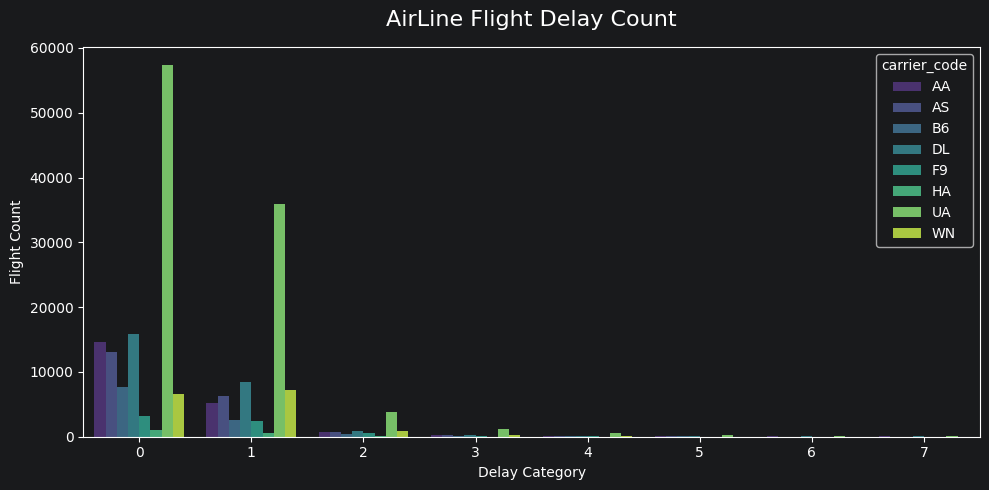

In [22]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5))

# Plot the airline flight delay count histogram
sns.countplot(data=df_train, x='target', hue='carrier_code', palette='viridis')
plt.title('AirLine Flight Delay Count', fontsize=16, pad=15)
plt.xlabel('Delay Category', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

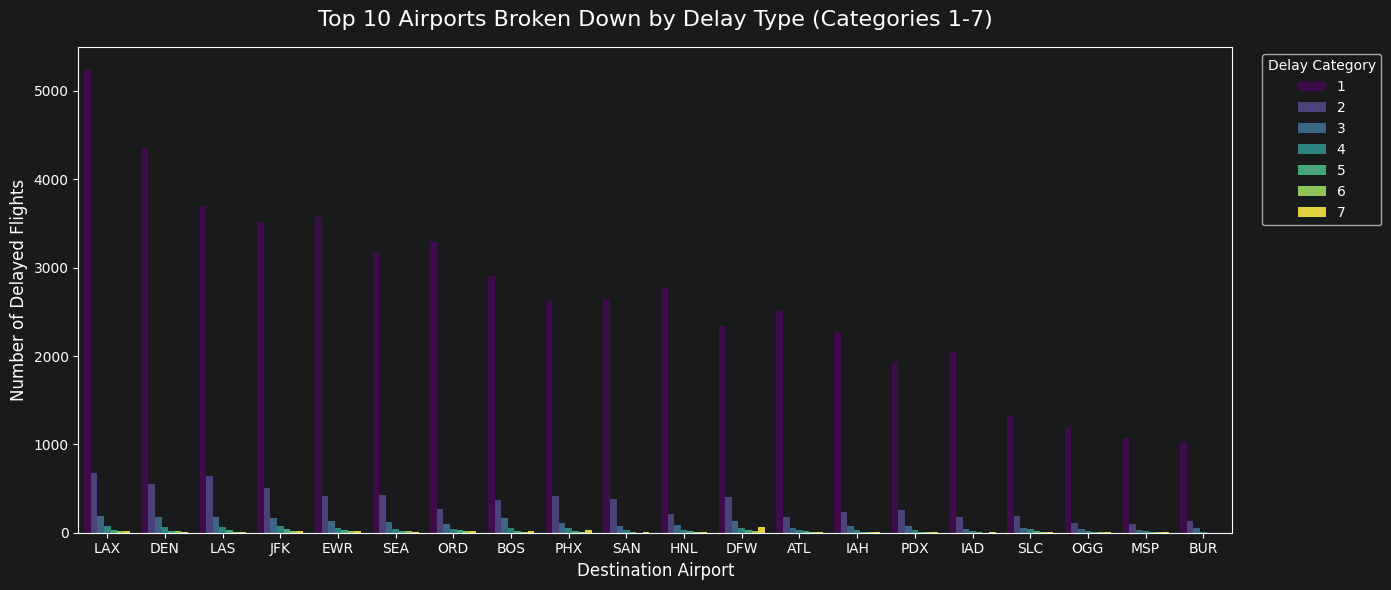

In [23]:
#Filter out on-time flights.
delayed_flights = df_train[df_train['target'] > 0]

# Only display the top 20 airports with most delay.
top_20_airports = delayed_flights['destination_airport'].value_counts().head(20).index
df_top_20_delayed = delayed_flights[delayed_flights['destination_airport'].isin(top_20_airports)]

# Set up the matplotlib figure
plt.figure(figsize=(14, 6))

# Plot the flight count histogram
sns.countplot(
    data=df_top_20_delayed,
    x='destination_airport',
    hue='target',
    order=top_20_airports,
    palette='viridis'
)

# Plot the flight count histogram
plt.title('Top 10 Airports Broken Down by Delay Type (Categories 1-7)', fontsize=16, pad=15)
plt.xlabel('Destination Airport', fontsize=12)
plt.ylabel('Number of Delayed Flights', fontsize=12)
plt.legend(title='Delay Category', bbox_to_anchor=(1.02, 1), loc='upper left')

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

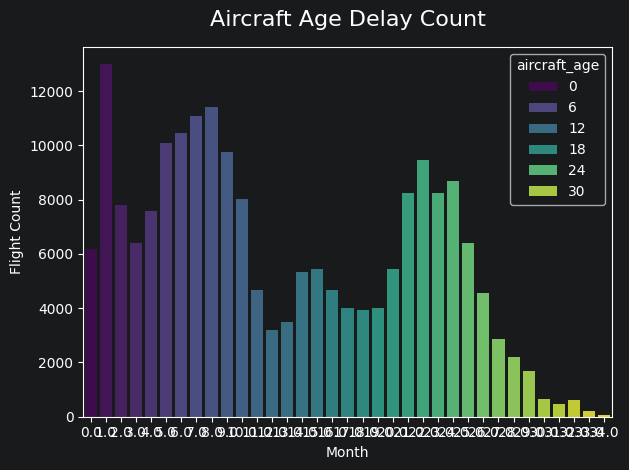

In [24]:
# Plot the aircraft age vs delay count histogram
sns.countplot(data=df_train, x='aircraft_age', hue='aircraft_age', palette='viridis', color='gold')
plt.title('Aircraft Age Delay Count', fontsize=16, pad=15)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

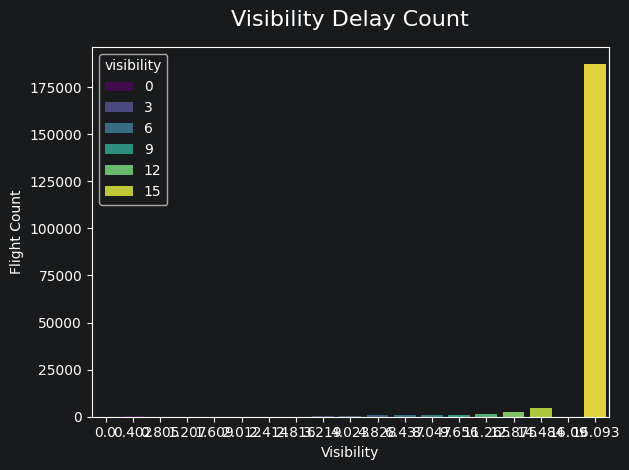

In [25]:
# Plot the visibility vs delay count histogram
sns.countplot(data=df_train, x='visibility', hue='visibility', palette='viridis', color='gold')
plt.title('Visibility Delay Count', fontsize=16, pad=15)
plt.xlabel('Visibility', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

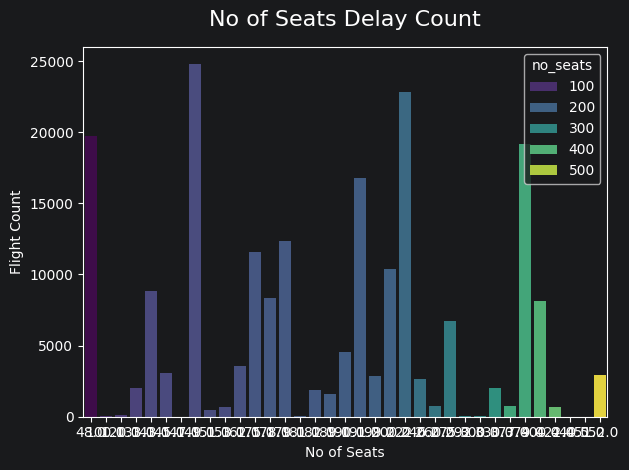

In [26]:
# Plot the num of seats vs delay count histogram
sns.countplot(data=df_train, x='no_seats', hue='no_seats', palette='viridis', color='gold')
plt.title('No of Seats Delay Count', fontsize=16, pad=15)
plt.xlabel('No of Seats', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

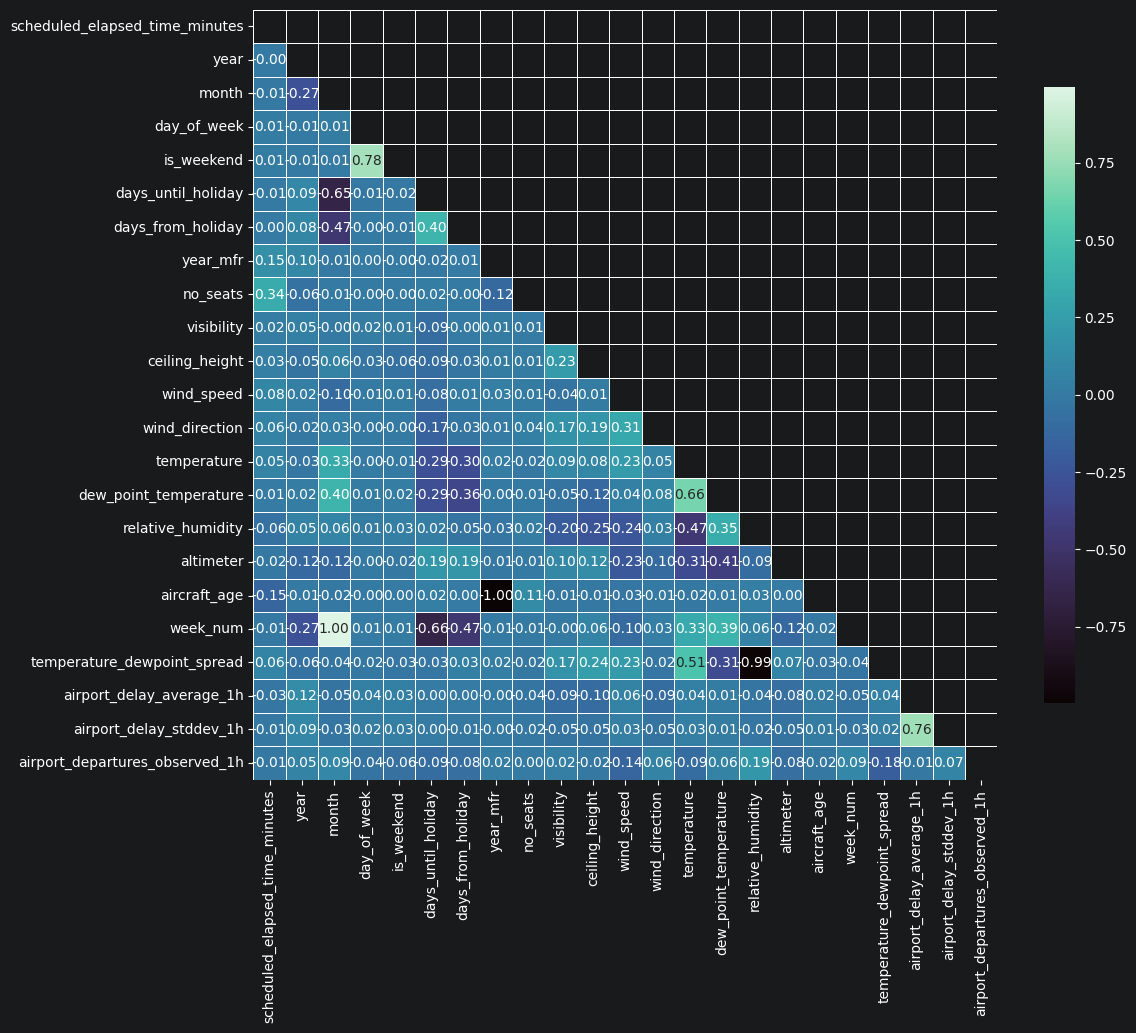

In [27]:
# Pick out the numerical data column for analysis
numeric_cols = [
    'scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend',
    'days_until_holiday', 'days_from_holiday', 'year_mfr', 'no_seats',
    'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature',
    'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num',
    'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h',
    'airport_departures_observed_1h'
]
# Create the correlation matrix
for col in numeric_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')

X_train[numeric_cols] = X_train[numeric_cols].fillna(0)

correlation_matrix = X_train[numeric_cols].corr()
# Create a mask to filter out the repeated output.
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib
plt.figure(figsize=(12, 10))

# Configure the correlation matrix
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='mako',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.show()

---
### <span style="color:chocolate">Improved Model</span>

In [18]:
# Initialize the HistGradientBoostingClassifier model
# Set the parameters based on the API and experiment/results from the previous ran/advise from the professors.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html
gb_classifier = HistGradientBoostingClassifier(
    # Auto-detects the pandas 'category' columns
    categorical_features="from_dtype",
    max_iter=600,
    learning_rate=0.01,
    max_depth=5,
    min_samples_leaf=200,
    # Stops training early if validation score stagnates
    n_iter_no_change=10,
    random_state=42
)

# Train the model
gb_classifier.fit(X_train, y_train)

HistGradientBoostingClassifier(learning_rate=0.01, max_depth=5, max_iter=600,
                               min_samples_leaf=200, random_state=42)

In [19]:
# Evaluate the train, validation, and test set.
train_accuracy = accuracy_score(y_train, gb_classifier.predict(X_train))
val_accuracy   = accuracy_score(y_val, gb_classifier.predict(X_val))
test_accuracy  = accuracy_score(y_test, gb_classifier.predict(X_test))

print('Training Accuracy:', train_accuracy)
print('Validation Accuracy:', val_accuracy)
print('Test Accuracy:', test_accuracy)

Training Accuracy: 0.6618924325645669
Validation Accuracy: 0.6830746666267566
Test Accuracy: 0.6454997156454847


<Figure size 1000x800 with 0 Axes>

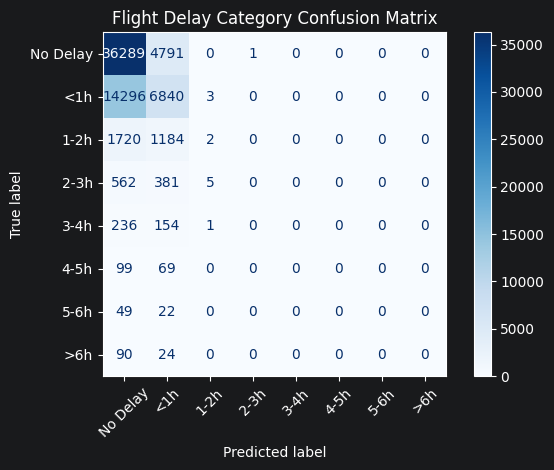

In [20]:
# Calculate the prediction on the testing data set.
y_test_pred = gb_classifier.predict(X_test)

# Plot the confusion matrix.
cm = confusion_matrix(y_test, y_test_pred)

# List out the class name for labeling.
delay_labels = ['No Delay', '<1h', '1-2h', '2-3h', '3-4h', '4-5h', '5-6h', '>6h']

# Confusion matrix settings
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=delay_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Flight Delay Category Confusion Matrix')

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()